In [ ]:

import os, warnings, gc
import numpy as np
import pandas as pd
import librosa
import scipy.signal
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import torch
import torchaudio
import torchaudio.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import json

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─── PATHS ────────────────────────────────────────────────────────────────
DATA_DIR   = 'dataset/'
LABELS_CSV = os.path.join(DATA_DIR, 'SEP-28k_labels.csv')
CLIPS_DIR  = 'dataset/clips/stuttering-clips/clips'
OUT_DIR    = 'output/features_v3'
os.makedirs(OUT_DIR, exist_ok=True)

CORPUS_SIZE = 20

SR           = 16_000
CLIP_SEC     = 3.0
CLIP_SAMPLES = int(SR * CLIP_SEC)

N_FFT      = 512
HOP_LENGTH = 160
N_MELS     = 64
N_MFCC     = 13
LPC_ORDER  = 16

F0_FMIN, F0_FMAX = 75.0, 500.0
F0_FRAME, F0_HOP = 512, 160

INTENSITY_SMOOTH = 11
STUTTER_TYPES = ['Prolongation', 'Block', 'SoundRep', 'WordRep', 'Interjection']

N_TIME_FRAMES = int(np.ceil(CLIP_SAMPLES / HOP_LENGTH))

# NEW dimensions
N_SYLL_PROSODY = 7          # [syll_dur, voiced_dur, delta_f0, dp, amp_tilt, dur_tilt, delta_energy]
N_FRAME_FEAT  = 39 + 13     # MFCC(39) + F0/Voiced/RMS/ZCR/VOPflag + 7 syllable prosody + syllable_pos
N_CLIP_FEAT   = 43          # 38 existing + 5 pause features

print(f"OUT_DIR:        {OUT_DIR}")
print(f"FRAME_FEAT_DIM: {N_FRAME_FEAT}")
print(f"CLIP_FEAT_DIM:  {N_CLIP_FEAT}")

In [ ]:


def levinson_durbin(r, order):
    """Solve Toeplitz system for LPC coefficients.
    CRITICAL FIX: previous code corrupted a[0] by updating a[:k].
    We now update ONLY a[1:k], preserving a[0]=1.0."""
    a = np.zeros(order + 1)
    a[0] = 1.0
    e = r[0]
    for k in range(1, order + 1):
        # r[k:0:-1]  -> r[k], r[k-1], ..., r[1]
        # a[:k]      -> a[0]=1, a[1], ..., a[k-1]
        lambda_val = -np.sum(a[:k] * r[k:0:-1]) / (e + 1e-12)
        a[k] = lambda_val
        if k > 1:
            # a[k-1:0:-1] -> a[k-1], a[k-2], ..., a[1]
            a[1:k] = a[1:k] + lambda_val * a[k - 1:0:-1]
        e = e * (1 - lambda_val ** 2)
    return a, e


def compute_lp_residual(y, order=LPC_ORDER):
    """Compute LP residual using Levinson-Durbin."""
    y = y.astype(np.float64)
    r = np.correlate(y, y, mode='full')
    r = r[len(r)//2:]
    r = r / (len(y) + 1e-12)
    a, _ = levinson_durbin(r, order)
    residual = scipy.signal.lfilter(a, [1.0], y)
    return residual.astype(np.float32)


def compute_hilbert_envelope(y):
    """Paper Eq.1: h_e(n) = sqrt(r^2(n) + r_h^2(n)) via scipy.signal.hilbert."""
    analytic = scipy.signal.hilbert(y)
    return np.abs(analytic).astype(np.float32)


def extract_f0_autocorrelation(y, sr=SR):
    """Extract F0 using autocorrelation on low-pass filtered signal."""
    if len(y) < F0_FRAME:
        return np.zeros(1, dtype=np.float32), np.zeros(1, dtype=bool)
    sos = scipy.signal.butter(4, 900, btype='low', fs=sr, output='sos')
    y_lp = scipy.signal.sosfilt(sos, y.astype(np.float64))
    frames = librosa.util.frame(y_lp, frame_length=F0_FRAME, hop_length=F0_HOP)
    n_frames = frames.shape[1]
    f0 = np.zeros(n_frames, dtype=np.float32)
    voiced = np.zeros(n_frames, dtype=bool)
    min_period = max(1, int(sr / F0_FMAX))
    max_period = int(sr / F0_FMIN)
    for i in range(n_frames):
        frame = frames[:, i]
        frame = frame - np.mean(frame)
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]
        if corr[0] < 1e-12:
            continue
        corr = corr / corr[0]
        search_start = min_period
        search_end = min(max_period, len(corr) - 1)
        if search_end <= search_start:
            continue
        peak_idx = search_start + np.argmax(corr[search_start:search_end])
        if corr[peak_idx] > 0.5 and peak_idx > 0:
            f0[i] = sr / peak_idx
            voiced[i] = True
    return f0, voiced


def detect_vops_paper(y, sr=SR, lp_order=LPC_ORDER):
    """
    VOP detection faithful to Mary & Yegnanarayana (2008), Section 5.3.
    1. LP residual
    2. Hilbert envelope of LP residual
    3. VOP evidence = convolve envelope with Gabor filter
    4. Peak picking with positive/negative thresholds
    5. F0-based spurious reduction
    """
    if len(y) < N_FFT:
        return np.array([], dtype=np.int64)

    # 1. LP residual
    residual = compute_lp_residual(y, order=lp_order)

    # 2. Hilbert envelope (Eq. 1)
    h_e = compute_hilbert_envelope(residual)

    # 3. VOP evidence: convolve with Gabor filter (Gaussian-windowed cosine)
    sigma_samp = int(0.020 * sr)          # 20 ms
    if sigma_samp < 1:
        sigma_samp = 1
    t = np.arange(-3 * sigma_samp, 3 * sigma_samp + 1)
    fc = 8.0                               # ~8 Hz syllable modulation
    gabor = np.exp(-t**2 / (2 * sigma_samp**2)) * np.cos(2 * np.pi * fc * t / sr)
    gabor = gabor / (np.sum(np.abs(gabor)) + 1e-12)
    vop_evidence = np.convolve(h_e, gabor, mode='same')

    # 4. Peak picking with positive/negative thresholds (Section 5.3)
    max_ev = np.max(vop_evidence)
    min_ev = np.min(vop_evidence)
    if max_ev <= 0:
        return np.array([], dtype=np.int64)

    scale_factor = 0.5
    pos_thresh = scale_factor * max_ev
    neg_thresh = scale_factor * min_ev     # min_ev is negative

    peaks, _ = scipy.signal.find_peaks(vop_evidence, height=pos_thresh)

    true_peaks = []
    for p in peaks:
        if len(true_peaks) == 0:
            true_peaks.append(p)
        else:
            segment = vop_evidence[true_peaks[-1]:p + 1]
            if np.min(segment) < neg_thresh:
                true_peaks.append(p)
            else:
                # No deep valley: first peak is spurious; keep stronger
                if vop_evidence[p] >= vop_evidence[true_peaks[-1]]:
                    true_peaks[-1] = p

    vop_samples = np.array(true_peaks, dtype=np.int64)

    # 5. Further reduction using F0 info (Section 5.3, last paragraph)
    # A true vowel onset must be followed by voicing within ~100 ms.
    f0_tmp, voiced_tmp = extract_f0_autocorrelation(y, sr)
    if len(vop_samples) > 0 and len(voiced_tmp) > 0:
        valid = []
        for v in vop_samples:
            vf = int(v / HOP_LENGTH)
            end_chk = min(vf + 10, len(voiced_tmp))
            if vf < len(voiced_tmp) and np.any(voiced_tmp[vf:end_chk]):
                valid.append(v)
        vop_samples = np.array(valid, dtype=np.int64)

    # Boundary cleaning
    vop_samples = vop_samples[(vop_samples > sr * 0.05) & (vop_samples < len(y) - sr * 0.05)]
    return np.unique(vop_samples)


def extract_syllable_prosody(y, sr, vops, f0, voiced, energy_db):
    """
    Extract 7 prosody parameters per syllable-like region (between VOPs).
    Sections 6.1 (Intonation), 6.2 (Rhythm), 6.3 (Stress).
    Returns:
        syll_prosody: (n_syllables, 7)
        syll_meta:    list of (start_frame, end_frame, start_samp, end_samp)
    """
    if len(vops) < 2:
        return np.zeros((0, N_SYLL_PROSODY), dtype=np.float32), []

    features = []
    syll_meta = []

    for i in range(len(vops) - 1):
        start_samp = vops[i]
        end_samp = vops[i + 1]
        start_frame = int(start_samp / HOP_LENGTH)
        end_frame = int(end_samp / HOP_LENGTH)
        end_frame = min(end_frame, len(f0))
        start_frame = min(start_frame, len(f0))
        if start_frame >= end_frame:
            continue

        # 1. Syllable duration (Dt in paper)
        syll_dur = (end_samp - start_samp) / sr

        # 2. Voiced duration within syllable (Dv)
        voiced_frames = voiced[start_frame:end_frame]
        voiced_dur = np.sum(voiced_frames) * HOP_LENGTH / sr

        # F0 segment
        f0_seg = f0[start_frame:end_frame].copy()
        valid_f0 = f0_seg[f0_seg > 0]

        # 3-6. F0 contour dynamics (Section 5.4, Fig.10)
        if len(valid_f0) > 0 and len(f0_seg) > 0:
            f0_start = f0_seg[0] if f0_seg[0] > 0 else valid_f0[0]
            f0_end = f0_seg[-1] if f0_seg[-1] > 0 else valid_f0[-1]
            f0p = np.max(valid_f0)
            f0v = np.min(valid_f0)
            delta_f0 = f0p - f0v

            # Dp: distance of F0 peak from VOP
            peak_rel = int(np.argmax(f0_seg))
            peak_samp = start_samp + peak_rel * HOP_LENGTH
            dp = (peak_samp - start_samp) / sr

            # Tilt parameters
            Ar = f0p - f0_start
            Af = f0p - f0_end
            Dr = dp
            Df = syll_dur - dp
            amp_tilt = (abs(Ar) - abs(Af)) / (abs(Ar) + abs(Af) + 1e-12)
            dur_tilt = (abs(Dr) - abs(Df)) / (abs(Dr) + abs(Df) + 1e-12)
        else:
            delta_f0 = 0.0
            dp = 0.0
            amp_tilt = 0.0
            dur_tilt = 0.0

        # 7. Delta energy: change in log energy in voiced regions (Section 6.3)
        energy_seg = energy_db[start_frame:end_frame]
        if len(energy_seg) > 0:
            if np.any(voiced_frames):
                ve = energy_seg[voiced_frames]
                delta_energy = np.max(ve) - np.min(ve)
            else:
                delta_energy = np.max(energy_seg) - np.min(energy_seg)
        else:
            delta_energy = 0.0

        features.append([syll_dur, voiced_dur, delta_f0, dp,
                         amp_tilt, dur_tilt, delta_energy])
        syll_meta.append((start_frame, end_frame, start_samp, end_samp))

    if len(features) == 0:
        return np.zeros((0, N_SYLL_PROSODY), dtype=np.float32), []
    return np.array(features, dtype=np.float32), syll_meta


def compute_cpp(y, sr=SR):
    if len(y) < N_FFT:
        return np.zeros(1, dtype=np.float32)
    frames = librosa.util.frame(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    n_frames = frames.shape[1]
    cpp = np.zeros(n_frames, dtype=np.float32)
    for i in range(n_frames):
        frame = frames[:, i] * np.hanning(N_FFT)
        spec = np.abs(np.fft.rfft(frame)) ** 2
        log_spec = np.log(spec + 1e-12)
        cepstrum = np.fft.ifft(log_spec).real
        min_quef = max(1, int(sr / 1000))
        max_quef = min(int(20 * sr / 1000), len(cepstrum) - 1)
        if min_quef >= max_quef:
            continue
        quef_range = np.arange(min_quef, max_quef)
        if len(quef_range) < 2:
            continue
        cep_range = cepstrum[min_quef:max_quef]
        A = np.vstack([quef_range, np.ones(len(quef_range))]).T
        m, c = np.linalg.lstsq(A, cep_range, rcond=None)[0]
        baseline = m * quef_range + c
        prominence = cep_range - baseline
        peak_idx = min_quef + np.argmax(prominence)
        cpp[i] = cepstrum[peak_idx] - (m * peak_idx + c)
    return cpp


def extract_formants(y, sr=SR, n_formants=3):
    if len(y) < N_FFT:
        return np.zeros((1, n_formants), dtype=np.float32)
    frames = librosa.util.frame(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    n_frames = frames.shape[1]
    formants = np.zeros((n_frames, n_formants), dtype=np.float32)
    for i in range(n_frames):
        frame = frames[:, i] * np.hanning(N_FFT)
        r = np.correlate(frame, frame, mode='full')
        r = r[len(r)//2:]
        r = r / (len(frame) + 1e-12)
        a, _ = levinson_durbin(r, LPC_ORDER)
        roots = np.roots(a)
        roots = roots[np.imag(roots) > 0]
        if len(roots) == 0:
            continue
        freqs = np.angle(roots) * sr / (2 * np.pi)
        bandwidths = -np.log(np.abs(roots)) * sr / np.pi
        valid = (freqs > 90) & (bandwidths < 400) & (freqs < sr / 2)
        valid_freqs = freqs[valid]
        if len(valid_freqs) > 0:
            sorted_idx = np.argsort(valid_freqs)
            n_take = min(n_formants, len(sorted_idx))
            formants[i, :n_take] = valid_freqs[sorted_idx[:n_take]]
    return formants


def compute_jitter(f0, voiced, sr=SR):
    if np.sum(voiced) < 2:
        return 0.0
    f0_v = f0[voiced]
    if len(f0_v) < 2 or np.mean(f0_v) < 1e-6:
        return 0.0
    periods = 1000.0 / (f0_v + 1e-12)
    period_diffs = np.abs(np.diff(periods))
    mean_period = np.mean(periods[:-1])
    return float(np.mean(period_diffs) / mean_period) if mean_period > 0 else 0.0


def compute_shimmer(y, f0, voiced, sr=SR):
    if np.sum(voiced) < 2:
        return 0.0
    voiced_idx = np.where(voiced)[0]
    if len(voiced_idx) < 2:
        return 0.0
    peak_amps = []
    for i in range(len(voiced_idx)):
        sample_start = voiced_idx[i] * F0_HOP
        sample_end = min(sample_start + F0_FRAME, len(y))
        if sample_start >= len(y):
            break
        segment = y[sample_start:sample_end]
        if len(segment) > 0:
            peak_amps.append(np.max(np.abs(segment)))
    peak_amps = np.array(peak_amps)
    if len(peak_amps) < 2:
        return 0.0
    amp_diffs = np.abs(np.diff(peak_amps))
    return float(np.mean(20 * np.log10((peak_amps[:-1] + amp_diffs) / peak_amps[:-1])))


def compute_spectral_flux(mfcc):
    if mfcc.shape[1] < 2:
        return np.zeros(mfcc.shape[1], dtype=np.float32)
    diff = np.diff(mfcc, axis=1)
    flux = np.zeros(mfcc.shape[1], dtype=np.float32)
    flux[1:] = np.sqrt(np.sum(diff ** 2, axis=0))
    return flux




def compute_pause_features(y, sr=SR, energy_thresh_db=-40.0, min_pause_ms=50):
    """
    Silence/pause features targeting Block stutters.
    Returns 5 scalars:
        pause_count, pause_dur_mean, pause_dur_std, silence_ratio, max_pause_dur
    A block is a pathological silent pause before a phoneme onset — directly
    captured here via energy-based VAD without needing syllable segmentation.
    """
    hop = HOP_LENGTH
    frame_len = N_FFT
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop)[0]
    rms_db = librosa.amplitude_to_db(rms + 1e-8)
    is_silence = rms_db < energy_thresh_db  # bool per frame

    min_pause_frames = max(1, int((min_pause_ms / 1000.0) * sr / hop))

    pause_durations = []
    count = 0
    for val in is_silence:
        if val:
            count += 1
        else:
            if count >= min_pause_frames:
                pause_durations.append(count * hop / sr)
            count = 0
    if count >= min_pause_frames:
        pause_durations.append(count * hop / sr)

    silence_ratio  = float(np.mean(is_silence))
    pause_count    = float(len(pause_durations))
    pause_dur_mean = float(np.mean(pause_durations)) if pause_durations else 0.0
    pause_dur_std  = float(np.std(pause_durations))  if pause_durations else 0.0
    max_pause_dur  = float(np.max(pause_durations))  if pause_durations else 0.0

    return pause_count, pause_dur_mean, pause_dur_std, silence_ratio, max_pause_dur

def compute_intensity_contour(y, sr=SR):
    if len(y) < N_FFT:
        return np.zeros(1, dtype=np.float32)
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH, frame_length=N_FFT)[0]
    intensity_db = 20 * np.log10(rms + 1e-12)
    if len(intensity_db) >= INTENSITY_SMOOTH:
        intensity_db = scipy.signal.savgol_filter(intensity_db, INTENSITY_SMOOTH, 2)
    return intensity_db.astype(np.float32)




In [ ]:


labels_df = pd.read_csv(LABELS_CSV)
labels_df['file_path'] = labels_df.apply(
    lambda row: os.path.join(CLIPS_DIR, f"{row['Show']}_{row['EpId']}_{row['ClipId']}.wav"), axis=1
)
labels_df['exists'] = labels_df['file_path'].apply(os.path.exists)
labels_df = labels_df[labels_df['exists']].copy()

labels_df['stutter_count'] = labels_df[STUTTER_TYPES].sum(axis=1)
labels_df['label'] = (labels_df['stutter_count'] > 0).astype(int)
labels_df['stutter_type'] = labels_df.apply(
    lambda row: ', '.join(s for s in STUTTER_TYPES if row.get(s, 0) > 0) or 'none', axis=1
)

if CORPUS_SIZE is not None and CORPUS_SIZE < len(labels_df):
    n_per_class = CORPUS_SIZE // 2
    stutter_df = labels_df[labels_df['label'] == 1].sample(
        n=min(n_per_class, len(labels_df[labels_df['label']==1])), random_state=42)
    clean_df = labels_df[labels_df['label'] == 0].sample(
        n=min(n_per_class, len(labels_df[labels_df['label']==0])), random_state=42)
    clips_df = pd.concat([stutter_df, clean_df]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    clips_df = labels_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Using {len(clips_df)} clips")
print(f"  Stutter: { (clips_df['label']==1).sum() }")
print(f"  Clean:   { (clips_df['label']==0).sum() }")




In [ ]:


def extract_all_features(y, sr=SR):
    """Extract frame-level (MFCC + syllable prosody) and clip-level features."""
    if len(y) == 0:
        return (np.zeros((N_TIME_FRAMES, N_FRAME_FEAT), dtype=np.float32),
                np.zeros(N_CLIP_FEAT, dtype=np.float32))

    if len(y) > CLIP_SAMPLES:
        y = y[:CLIP_SAMPLES]
    else:
        y = np.pad(y, (0, CLIP_SAMPLES - len(y)), mode='constant')

    y = y.astype(np.float32)
    y_pre = librosa.effects.preemphasis(y, coef=0.97)

    # MFCC + deltas
    mfcc = librosa.feature.mfcc(
        y=y_pre, sr=sr, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    n_frames = mfcc.shape[1]

    # F0 & voicing
    f0, voiced = extract_f0_autocorrelation(y, sr)
    if len(f0) != n_frames:
        if len(f0) > 1:
            f0 = np.interp(np.linspace(0, len(f0)-1, n_frames), np.arange(len(f0)), f0)
        else:
            f0 = np.zeros(n_frames, dtype=np.float32)
        if len(voiced) > 1:
            v_interp = np.interp(np.linspace(0, len(voiced)-1, n_frames),
                                 np.arange(len(voiced)), voiced.astype(float))
            voiced = v_interp > 0.5
        else:
            voiced = np.zeros(n_frames, dtype=bool)

    # RMS & log energy
    rms = librosa.feature.rms(y=y_pre, hop_length=HOP_LENGTH, frame_length=N_FFT)[0]
    if len(rms) != n_frames:
        rms = np.interp(np.linspace(0, max(len(rms)-1,0), n_frames),
                        np.arange(len(rms)), rms) if len(rms) > 0 else np.zeros(n_frames)
    energy_db = 20 * np.log10(rms + 1e-12)

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH, frame_length=N_FFT)[0]
    if len(zcr) != n_frames:
        zcr = np.interp(np.linspace(0, max(len(zcr)-1,0), n_frames),
                        np.arange(len(zcr)), zcr) if len(zcr) > 0 else np.zeros(n_frames)

    # ─── PAPER-BASED VOP & SYLLABLE PROSODY ─────────────────────────────
    vops = detect_vops_paper(y, sr)
    syll_prosody, syll_meta = extract_syllable_prosody(y, sr, vops, f0, voiced, energy_db)

    # Map syllable prosody to frames
    syll_dur_frame   = np.zeros(n_frames, dtype=np.float32)
    voiced_dur_frame = np.zeros(n_frames, dtype=np.float32)
    delta_f0_frame   = np.zeros(n_frames, dtype=np.float32)
    dp_frame         = np.zeros(n_frames, dtype=np.float32)
    amp_tilt_frame   = np.zeros(n_frames, dtype=np.float32)
    dur_tilt_frame   = np.zeros(n_frames, dtype=np.float32)
    delta_energy_frame = np.zeros(n_frames, dtype=np.float32)
    syll_pos_frame   = np.zeros(n_frames, dtype=np.float32)

    for (sf, ef, ss, es), pros in zip(syll_meta, syll_prosody):
        if sf >= n_frames:
            continue
        ef = min(ef, n_frames)
        syll_dur_frame[sf:ef]   = pros[0]
        voiced_dur_frame[sf:ef] = pros[1]
        delta_f0_frame[sf:ef]   = pros[2]
        dp_frame[sf:ef]         = pros[3]
        amp_tilt_frame[sf:ef]   = pros[4]
        dur_tilt_frame[sf:ef]   = pros[5]
        delta_energy_frame[sf:ef] = pros[6]
        nf = ef - sf
        if nf > 0:
            syll_pos_frame[sf:ef] = np.arange(nf) / nf

    # VOP flags
    vop_flags = np.zeros(n_frames, dtype=np.float32)
    for v in vops:
        fi = int(v / HOP_LENGTH)
        if 0 <= fi < n_frames:
            vop_flags[fi] = 1.0

    # Stack frame features: 39 + 13 = 52
    frame_feats = np.vstack([
        mfcc, mfcc_delta, mfcc_delta2,        # 0-38
        f0.reshape(1, -1),                     # 39
        voiced.astype(float).reshape(1, -1),   # 40
        rms.reshape(1, -1),                    # 41
        zcr.reshape(1, -1),                    # 42
        vop_flags.reshape(1, -1),              # 43
        syll_dur_frame.reshape(1, -1),         # 44
        voiced_dur_frame.reshape(1, -1),       # 45
        delta_f0_frame.reshape(1, -1),         # 46
        dp_frame.reshape(1, -1),               # 47
        amp_tilt_frame.reshape(1, -1),         # 48
        dur_tilt_frame.reshape(1, -1),         # 49
        delta_energy_frame.reshape(1, -1),     # 50
        syll_pos_frame.reshape(1, -1),         # 51
    ]).T

    out_frame = np.zeros((N_TIME_FRAMES, N_FRAME_FEAT), dtype=np.float32)
    n = min(N_TIME_FRAMES, frame_feats.shape[0])
    out_frame[:n] = frame_feats[:n]

    # ─── CLIP-LEVEL FEATURES ──────────────────────────────────────────────
    if len(syll_prosody) > 0:
        sp_mean = np.mean(syll_prosody, axis=0)
        sp_std  = np.std(syll_prosody, axis=0)
    else:
        sp_mean = np.zeros(N_SYLL_PROSODY, dtype=np.float32)
        sp_std  = np.zeros(N_SYLL_PROSODY, dtype=np.float32)

    syllable_rate = len(syll_prosody) / (len(y) / sr + 1e-9)

    f0_v = f0[voiced] if np.any(voiced) else np.array([])
    f0_mean = float(np.mean(f0_v)) if len(f0_v) > 0 else 0.0
    f0_std  = float(np.std(f0_v))  if len(f0_v) > 0 else 0.0
    f0_min  = float(np.min(f0_v))  if len(f0_v) > 0 else 0.0
    f0_max  = float(np.max(f0_v))  if len(f0_v) > 0 else 0.0
    f0_range = f0_max - f0_min
    voiced_ratio = float(np.mean(voiced))

    jitter  = compute_jitter(f0, voiced, sr)
    shimmer = compute_shimmer(y, f0, voiced, sr)

    cpp_vals = compute_cpp(y, sr)
    cpp_mean = float(np.mean(cpp_vals)) if len(cpp_vals) > 0 else 0.0
    cpp_std  = float(np.std(cpp_vals))  if len(cpp_vals) > 0 else 0.0

    formants = extract_formants(y, sr)
    f1_m = float(np.median(formants[:,0][formants[:,0]>0])) if np.any(formants[:,0]>0) else 0.0
    f2_m = float(np.median(formants[:,1][formants[:,1]>0])) if np.any(formants[:,1]>0) else 0.0
    f3_m = float(np.median(formants[:,2][formants[:,2]>0])) if np.any(formants[:,2]>0) else 0.0

    flux = compute_spectral_flux(mfcc)
    flux_mean = float(np.mean(flux))
    flux_max  = float(np.max(flux))

    intensity = compute_intensity_contour(y, sr)
    int_mean = float(np.mean(intensity)) if len(intensity) > 0 else 0.0
    int_std  = float(np.std(intensity))  if len(intensity) > 0 else 0.0

    # ─── PAUSE / SILENCE FEATURES ──────────────────────────────────────────
    p_count, p_mean, p_std, sil_ratio, max_p = compute_pause_features(y, sr)

    rms_mean = float(np.mean(rms))
    rms_std  = float(np.std(rms))
    zcr_mean = float(np.mean(zcr))

    clip_feats = np.array([
        *sp_mean, *sp_std,                    # 14
        syllable_rate, float(len(syll_prosody)),  # 2
        f0_mean, f0_std, f0_min, f0_max, f0_range,  # 5
        voiced_ratio,                          # 1
        jitter, shimmer,                       # 2
        cpp_mean, cpp_std,                     # 2
        f1_m, f2_m, f3_m,                      # 3
        flux_mean, flux_max,                   # 2
        int_mean, int_std,                     # 2
        rms_mean, rms_std, zcr_mean,           # 3
        float(len(vops)), len(y)/sr,           # 2  -> 38
        p_count, p_mean, p_std, sil_ratio, max_p,  # 5 pause -> 43
    ], dtype=np.float32)

    # Clip feats should now be exactly N_CLIP_FEAT=43; safety truncate only
    clip_feats = clip_feats[:N_CLIP_FEAT]

    return out_frame, clip_feats




In [ ]:


frame_list, clip_list, label_list, meta_list = [], [], [], []
failed = 0
failed_keys = []

for idx, row in tqdm(clips_df.iterrows(), total=len(clips_df), desc='Extracting'):
    try:
        waveform, native_sr = torchaudio.load(row['file_path'])
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if native_sr != SR:
            waveform = T.Resample(native_sr, SR)(waveform)
        y = waveform.squeeze(0).numpy() if waveform.dim() == 2 else waveform.numpy()

        if len(y) == 0 or np.all(y == 0):
            raise ValueError("Empty or silent audio")

        frame_feat, clip_feat = extract_all_features(y, SR)

        assert frame_feat.shape == (N_TIME_FRAMES, N_FRAME_FEAT)
        assert clip_feat.shape == (N_CLIP_FEAT,)

        frame_list.append(frame_feat)
        clip_list.append(clip_feat)
        label_list.append(row['label'])
        meta_list.append({
            'clip_key': f"{row['Show']}_{row['EpId']}_{row['ClipId']}",
            'file_path': row['file_path'],
            'show': row['Show'],
            'ep_id': int(row['EpId']),
            'clip_id': int(row['ClipId']),
            'label': int(row['label']),
            'stutter_type': row['stutter_type'],
            'duration': float(len(y)) / SR,
        })
    except Exception as e:
        failed += 1
        key = f"{row['Show']}_{row['EpId']}_{row['ClipId']}"
        failed_keys.append((key, type(e).__name__, str(e)))
        if failed <= 5:
            print(f"  FAIL #{failed} {key}: {type(e).__name__}: {str(e)[:100]}")
    if idx % 200 == 0:
        gc.collect()

if len(frame_list) == 0:
    raise RuntimeError("No clips extracted — check errors above")

In [ ]:
X_frame = np.stack(frame_list).astype(np.float32)
X_clip  = np.stack(clip_list).astype(np.float32)
y_labels = np.array(label_list, dtype=np.int64)

print(f"\nExtracted: {len(y_labels):,} clips  ({failed} failed)")
print(f"X_frame:   {X_frame.shape}")
print(f"X_clip:    {X_clip.shape}")
print(f"y_labels:  {y_labels.shape}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ⑥ VISUALIZATION (updated indices for 52-dim frame features)
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec

clean_idx   = np.random.choice(np.where(y_labels == 0)[0], 1)[0]
stutter_idx = np.random.choice(np.where(y_labels == 1)[0], 1)[0]
random_idx  = np.random.randint(0, len(y_labels))

selected_indices = [clean_idx, stutter_idx, random_idx]
selected_labels  = ['No Stutter', 'Stutter', f"Random ({'Stutter' if y_labels[random_idx] else 'Clean'})"]
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig = plt.figure(figsize=(22, 28))
gs = gridspec.GridSpec(6, 3, figure=fig, hspace=0.45, wspace=0.35)

for col, (idx, label, color) in enumerate(zip(selected_indices, selected_labels, colors)):
    meta = meta_list[idx]

    # 1. Waveform
    ax = fig.add_subplot(gs[0, col])
    try:
        w, sr = torchaudio.load(meta['file_path'])
        if w.shape[0] > 1: w = w.mean(dim=0)
        y_raw = w.squeeze().numpy()
        if len(y_raw) > CLIP_SAMPLES: y_raw = y_raw[:CLIP_SAMPLES]
        t = np.linspace(0, len(y_raw)/SR, len(y_raw))
        ax.plot(t, y_raw, color=color, lw=0.4, alpha=0.85)
    except:
        ax.text(0.5, 0.5, 'Waveform\nunavailable', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'{label}\n{meta["clip_key"]}', fontsize=11, color=color, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')

    # 2. Frame-level heatmap
    ax = fig.add_subplot(gs[1, col])
    frame_data = X_frame[idx].T
    im = ax.imshow(frame_data, aspect='auto', origin='lower', cmap='viridis',
                   extent=[0, 3, 0, N_FRAME_FEAT])
    ax.set_title('Frame-Level Features (52 dims × 300 frames)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Feature Index')
    ax.set_yticks([0, 13, 26, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51])
    ax.set_yticklabels(['MFCC0','ΔMFCC0','ΔΔMFCC0','F0','Voi','RMS','ZCR','VOP',
                        'SyllDur','VoicedDur','ΔF0','Dp','AmpTilt','DurTilt','ΔE','SyllPos'],
                       fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

    # 3. MFCC only
    ax = fig.add_subplot(gs[2, col])
    mfcc_only = X_frame[idx, :, :13].T
    im2 = ax.imshow(mfcc_only, aspect='auto', origin='lower', cmap='coolwarm', extent=[0, 3, 1, 14])
    ax.set_title('MFCC Coefficients (13)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('MFCC Index')
    plt.colorbar(im2, ax=ax, fraction=0.046)

    # 4. Prosody contours: F0 + RMS + ZCR
    ax = fig.add_subplot(gs[3, col])
    times = np.linspace(0, 3, N_TIME_FRAMES)
    ax.plot(times, X_frame[idx, :, 39], color=color, lw=1.5, label='F0 (Hz)', alpha=0.9)
    ax2 = ax.twinx()
    ax2.plot(times, X_frame[idx, :, 41], color='#7f8c8d', lw=1, alpha=0.6, label='RMS')
    ax2.plot(times, X_frame[idx, :, 42], color='#f39c12', lw=1, alpha=0.6, label='ZCR')
    ax.set_title('Prosody Contours: F0 + RMS + ZCR', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('F0 (Hz)', color=color)
    ax2.set_ylabel('RMS / ZCR', color='#7f8c8d')
    ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

    # 5. Voicing + VOP flags + Syllable position
    ax = fig.add_subplot(gs[4, col])
    ax.fill_between(times, X_frame[idx, :, 40], alpha=0.3, color='green', label='Voiced')
    vop_times = times[X_frame[idx, :, 43] > 0.5]
    ax.scatter(vop_times, np.ones_like(vop_times)*1.05, color='red', s=30, marker='v', label='VOP', zorder=5)
    ax.plot(times, X_frame[idx, :, 51], color='purple', lw=1, alpha=0.7, label='SyllPos')
    ax.set_title('Voicing, VOPs & Syllable Position', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Value')
    ax.set_ylim(-0.1, 1.3); ax.legend(fontsize=8)

    # 6. Clip-level bar chart
    ax = fig.add_subplot(gs[5, col])
    clip_data = X_clip[idx]
    feat_names = [
        'SyllDurμ','VoicedDurμ','ΔF0μ','Dpμ','AmpTiltμ','DurTiltμ','ΔEμ',
        'SyllDurσ','VoicedDurσ','ΔF0σ','Dpσ','AmpTiltσ','DurTiltσ','ΔEσ',
        'SyllRate','nSyll','F0μ','F0σ','F0min','F0max','F0rng','Voi%',
        'Jitt','Shim','CPPμ','CPPσ','F1','F2','F3','Fluxμ','Fluxmx',
        'Intμ','Intσ','RMSμ','RMSσ','ZCR','nVOP','Dur',
        'PauseCnt','PauseMu','PauseSig','SilRatio','MaxPause'
    ]
    y_pos = np.arange(len(clip_data))
    bars = ax.barh(y_pos, clip_data, color=color, alpha=0.7)
    ax.set_yticks(y_pos); ax.set_yticklabels(feat_names, fontsize=7)
    ax.set_xlabel('Value')
    ax.set_title('Clip-Level Features (43-dim)', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, clip_data):
        if abs(val) > 0.01:
            ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
                    va='center', ha='left' if val>0 else 'right', fontsize=6, color='black')

fig.suptitle('3 Random Clips: MFCC + Paper-Based Syllable Prosody\n(Clean | Stutter | Random)',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig(os.path.join(OUT_DIR, 'three_clips_all_features.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ⑦ SAVE + MANIFEST
# ═══════════════════════════════════════════════════════════════════════════

np.save(os.path.join(OUT_DIR, 'X_frame.npy'), X_frame)
np.save(os.path.join(OUT_DIR, 'X_clip.npy'), X_clip)
np.save(os.path.join(OUT_DIR, 'y_labels.npy'), y_labels)

with open(os.path.join(OUT_DIR, 'metadata.jsonl'), 'w') as f:
    for m in meta_list:
        f.write(json.dumps(m) + '\n')

manifest = {
    "dataset": "SEP-28k",
    "extraction_version": "3.0_paper_based",
    "paper": "Mary & Yegnanarayana (2008), Speech Communication",
    "date": "2026-04-23",
    "corpus_size": CORPUS_SIZE if CORPUS_SIZE else "ALL",
    "n_clips": int(len(y_labels)),
    "n_failed": int(failed),
    "shapes": {
        "X_frame": list(X_frame.shape),
        "X_clip": list(X_clip.shape),
        "y_labels": list(y_labels.shape),
    },
    "files": {
        "X_frame.npy": {
            "description": "Frame-level MFCC + syllable-anchored prosody for CNN+LSTM",
            "shape": list(X_frame.shape),
            "dtype": str(X_frame.dtype),
            "feature_groups": {
                "MFCC_static":  [0, 13],
                "MFCC_delta":   [13, 26],
                "MFCC_delta2":  [26, 39],
                "F0": 39, "Voiced": 40, "RMS": 41, "ZCR": 42, "VOP_flag": 43,
                "Syllable_duration": 44,
                "Voiced_duration_in_syllable": 45,
                "Delta_F0": 46,
                "Dp_peak_distance_from_VOP": 47,
                "Amplitude_tilt_At": 48,
                "Duration_tilt_Tlt": 49,
                "Delta_energy_DE": 50,
                "Syllable_position": 51,
            }
        },
        "X_clip.npy": {
            "description": "Clip-level statistics over syllable prosody vectors + conventional stats",
            "shape": list(X_clip.shape),
            "dtype": str(X_clip.dtype),
            "feature_groups": {
                "Syllable_prosody_mean": [0, 7],
                "Syllable_prosody_std":  [7, 14],
                "Syllable_rate": 14, "n_syllables": 15,
                "F0_stats": [16, 21], "Voiced_ratio": 21,
                "Jitter": 22, "Shimmer": 23,
                "CPP_stats": [24, 26],
                "Formants_F1F2F3": [26, 29],
                "Spectral_flux": [29, 31],
                "Intensity_stats": [31, 33],
                "RMS_stats": [33, 35], "ZCR_mean": 35,
                "n_VOPs": 36, "Duration_sec": 37,
            }
        },
        "y_labels.npy": {
            "description": "Binary labels: 0=no stutter, 1=stutter",
            "shape": list(y_labels.shape),
            "class_balance": {"0": int((y_labels==0).sum()), "1": int((y_labels==1).sum())},
        }
    }
}

In [ ]:

with open(os.path.join(OUT_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"\nSAVED TO: {OUT_DIR}")
for fn in ['X_frame.npy', 'X_clip.npy', 'y_labels.npy', 'metadata.jsonl', 'manifest.json']:
    fp = os.path.join(OUT_DIR, fn)
    if os.path.exists(fp):
        print(f"  {fn:20s}  {os.path.getsize(fp)/1e6:8.2f} MB")

In [ ]:


# !pip install -q scikit-learn

# %% [code]
import os, json, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings_ignored = True  # Set to False to see warnings
if warnings_ignored:
    import warnings
    warnings.filterwarnings('ignore')

# ─── SEED ─────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── PATHS ──────────────────────────────────────────────────────────────
FEAT_DIR = 'output/features_v3'
OUT_DIR = 'output/working/models'
os.makedirs(OUT_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 60
LR = 5e-4 
WD = 1e-3 
WARMUP_EPOCHS = 10
LR_PATIENCE = 10 
LR_FACTOR = 0.5 
EARLY_STOP = 20       # enough room after LR drops

# ─── LOAD FEATURES ────────────────────────────────────────────────────────
print("Loading features from Notebook 1...")

X_frame_path = os.path.join(FEAT_DIR, 'X_frame.npy')
X_clip_path = os.path.join(FEAT_DIR, 'X_clip.npy')
y_path = os.path.join(FEAT_DIR, 'y_labels.npy')
meta_path = os.path.join(FEAT_DIR, 'metadata.jsonl')

# Verify files exist
for p in [X_frame_path, X_clip_path, y_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}. Run Notebook 1 first.")

X_frame = np.load(X_frame_path)
X_clip = np.load(X_clip_path)
y = np.load(y_path)

print(f"X_frame: {X_frame.shape}  dtype={X_frame.dtype}")
print(f"X_clip:  {X_clip.shape}  dtype={X_clip.dtype}")
print(f"y:       {y.shape}  dtype={y.dtype}")

# Infer dimensions
N_CLIPS, N_TIME_FRAMES, N_FRAME_FEAT = X_frame.shape
N_CLIP_FEAT = X_clip.shape[1]

assert X_clip.shape[0] == N_CLIPS, "X_frame and X_clip have different N"
assert len(y) == N_CLIPS, "Labels count mismatch"

# ─── LOAD METADATA (optional, for analysis) ─────────────────────────────
meta_list = []
if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        for line in f:
            meta_list.append(json.loads(line.strip()))
    print(f"Metadata: {len(meta_list)} clips loaded")

# ─── TRAIN/VAL/TEST SPLIT ───────────────────────────────────────────────
# Stratified split preserving class ratio
# First: separate features and labels
indices = np.arange(N_CLIPS)

# 70/15/15 split
idx_train, idx_temp = train_test_split(
    indices, test_size=0.40, stratify=y
)

idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y[idx_temp]
)


# Extract subsets
X_frame_train, X_frame_val, X_frame_test = X_frame[idx_train], X_frame[idx_val], X_frame[idx_test]
X_clip_train, X_clip_val, X_clip_test = X_clip[idx_train], X_clip[idx_val], X_clip[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"\n{'='*50}")
print(f"Data splits:")
print(f"  Train: {len(y_train)}  (stutter={(y_train==1).sum()}, clean={(y_train==0).sum()})")
print(f"  Val:   {len(y_val)}    (stutter={(y_val==1).sum()}, clean={(y_val==0).sum()})")
print(f"  Test:  {len(y_test)}   (stutter={(y_test==1).sum()}, clean={(y_test==0).sum()})")

# ─── DEVICE ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Loading features from Notebook 1...
X_frame: (1994, 300, 52)  dtype=float32
X_clip:  (1994, 43)  dtype=float32
y:       (1994,)  dtype=int64
Metadata: 1994 clips loaded

Data splits:
  Train: 1196  (stutter=597, clean=599)
  Val:   399    (stutter=199, clean=200)
  Test:  399   (stutter=199, clean=200)

Device: cpu


In [ ]:




class StutterDataset(Dataset):
    def __init__(self, X_frame, X_clip, y):
        # Replace NaN/Inf with 0 before converting to tensor
        X_frame = np.nan_to_num(X_frame, nan=0.0, posinf=0.0, neginf=0.0)
        X_clip  = np.nan_to_num(X_clip,  nan=0.0, posinf=0.0, neginf=0.0)

        self.X_frame = torch.tensor(X_frame, dtype=torch.float32)
        self.X_clip  = torch.tensor(X_clip,  dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_frame[idx], self.X_clip[idx], self.y[idx]



# 70/15/15 split
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y[idx_temp]
)

idx_train, idx_temp = train_test_split(
    indices, test_size=0.40, stratify=y
)


# Extract subsets
X_frame_train, X_frame_val, X_frame_test = X_frame[idx_train], X_frame[idx_val], X_frame[idx_test]
X_clip_train, X_clip_val, X_clip_test = X_clip[idx_train], X_clip[idx_val], X_clip[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"\n{'='*50}")
print(f"Data splits:")
print(f"  Train: {len(y_train)}  (stutter={(y_train==1).sum()}, clean={(y_train==0).sum()})")
print(f"  Val:   {len(y_val)}    (stutter={(y_val==1).sum()}, clean={(y_val==0).sum()})")
print(f"  Test:  {len(y_test)}   (stutter={(y_test==1).sum()}, clean={(y_test==0).sum()})")

# ─── DEVICE ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



train_ds = StutterDataset(X_frame_train, X_clip_train, y_train)
val_ds = StutterDataset(X_frame_val, X_clip_val, y_val)
test_ds = StutterDataset(X_frame_test, X_clip_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=2, pin_memory=True)

print(f"Dataloaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")




class TemporalBranch(nn.Module):
    """
    Branch 1: CNN-LSTM on frame-level features.
    Input:  (batch, time=300, features=45)
    Output: (batch, 128) clip embedding
    """
    def __init__(self, n_time=300, n_feat=45, hidden=64, out_dim=128):
        super().__init__()

        # Conv1D: processes (batch, features, time)
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(128, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )

        # After 2 MaxPool1d(2): time -> 300/4 = 75
        conv_time = n_time // 4

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=hidden,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Self-attention
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden * 2,
            num_heads=4,
            batch_first=True
        )

        # Projection to embedding
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        # x: (batch, time, feat) -> (batch, feat, time) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv(x)           # (batch, hidden, time/4)
        x = x.permute(0, 2, 1)     # (batch, time/4, hidden)

        # LSTM
        x, _ = self.lstm(x)        # (batch, time/4, hidden*2)

        # Attention pooling
        attn_out, attn_weights = self.attention(x, x, x)
        x = attn_out.mean(dim=1)   # (batch, hidden*2)

        # Projection
        x = self.fc(x)             # (batch, out_dim)
        return x


class ProsodyBranch(nn.Module):
    """
    Branch 2: MLP on clip-level derived features.
    Input:  (batch, 32)
    Output: (batch, 16) prosody embedding
    """
    def __init__(self, in_dim=32, hidden1=64, hidden2=32, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden2, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class StutterClassifier(nn.Module):
    """
    Dual-branch ensemble classifier.
    """
    def __init__(self, temporal_dim=128, prosody_dim=16):
        super().__init__()
        self.temporal = TemporalBranch(
            n_time=N_TIME_FRAMES, 
            n_feat=N_FRAME_FEAT, 
            out_dim=temporal_dim
        )
        self.prosody = ProsodyBranch(
            in_dim=N_CLIP_FEAT, 
            out_dim=prosody_dim
        )

        # Fusion classifier
        fusion_dim = temporal_dim + prosody_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, x_frame, x_clip):
        emb_t = self.temporal(x_frame)    # (batch, 128)
        emb_p = self.prosody(x_clip)       # (batch, 16)
        emb = torch.cat([emb_t, emb_p], dim=1)  # (batch, 144)
        return self.fusion(emb)             # (batch, 1) — logits


# %% [code]
print("NaN check:")
print(f"  X_frame NaNs: {np.isnan(X_frame).sum()} ({np.isnan(X_frame).mean()*100:.2f}%)")
print(f"  X_clip  NaNs: {np.isnan(X_clip).sum()} ({np.isnan(X_clip).mean()*100:.2f}%)")
# Find which clip-level features have NaNs
nan_cols = np.where(np.isnan(X_clip).any(axis=0))[0]
print(f"  X_clip NaN columns: {nan_cols}")



Data splits:
  Train: 1196  (stutter=597, clean=599)
  Val:   399    (stutter=199, clean=200)
  Test:  399   (stutter=199, clean=200)

Device: cpu
Dataloaders ready:
  Train batches: 19
  Val batches:   7
  Test batches:  7
NaN check:
  X_frame NaNs: 0 (0.00%)
  X_clip  NaNs: 2 (0.00%)
  X_clip NaN columns: [23]


In [ ]:

model = StutterClassifier(temporal_dim=128, prosody_dim=16).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

# Class imbalance handling
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

pos_weight = torch.tensor([n_neg / max(n_pos, 1) * 2], dtype=torch.float32).to(DEVICE)
print(f"Class weights: pos={pos_weight.item():.2f} (n_pos={n_pos}, n_neg={n_neg})")

# Loss: BCEWithLogitsLoss (more stable than BCE + Sigmoid)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer: AdamW with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=LR_FACTOR, patience=LR_PATIENCE)

# %% [code]
# ═══════════════════════════════════════════════════════════════════════════
# ⑤ TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x_frame, x_clip, labels in loader:
        x_frame = x_frame.to(DEVICE)
        x_clip = x_clip.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x_frame, x_clip)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * len(labels)
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_frame, x_clip, labels in loader:
            x_frame = x_frame.to(DEVICE)
            x_clip = x_clip.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(x_frame, x_clip)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)

            all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def compute_metrics(y_true, y_prob, threshold=0.5):
    """Compute classification metrics."""
    y_pred = (y_prob > threshold).astype(int)

    acc = (y_pred == y_true).mean()
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        'accuracy': acc,
        'auc': auc,
        'f1': f1,
        'precision': (y_pred[y_true==1] == 1).mean() if (y_true==1).sum() > 0 else 0,
        'recall': (y_pred[y_true==1] == 1).sum() / max((y_true==1).sum(), 1),
    }


# ─── TRAINING ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"STARTING TRAINING")
print(f"{'='*60}")

best_auc = 0
best_state = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_preds, train_labels = train_epoch(model, train_loader, criterion, optimizer)

    # Validate
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion)
    
    # Metrics
    val_metrics = compute_metrics(val_labels, val_preds)
    train_metrics = compute_metrics(train_labels, train_preds)

    # Scheduler step
    scheduler.step(val_metrics['auc'])

    # History
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_metrics['auc'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])

    # Print
    if epoch % 10 == 0 : 
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val AUC: {val_metrics['auc']:.4f} | "
              f"Val F1: {val_metrics['f1']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f}")

    # Early stopping
    if val_metrics['auc'] > best_auc:
        best_auc = val_metrics['auc']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        # Save best
        torch.save(best_state, os.path.join(OUT_DIR, 'best_model.pt'))
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOP:
        print(f"\nEarly stopping at epoch {epoch}. Best Val AUC: {best_auc:.4f}")
        break

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model (Val AUC: {best_auc:.4f})")

# %% [code]
# ═══════════════════════════════════════════════════════════════════════════
# ⑥ EVALUATION ON TEST SET
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"TEST SET EVALUATION")
print(f"{'='*60}")

test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion)
test_metrics = compute_metrics(test_labels, test_preds)

print(f"Test Loss:    {test_loss:.4f}")
print(f"Test AUC:     {test_metrics['auc']:.4f}")
print(f"Test F1:      {test_metrics['f1']:.4f}")
print(f"Test Acc:     {test_metrics['accuracy']:.4f}")
print(f"Test Recall:  {test_metrics['recall']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")

# Classification report
y_pred = (test_preds > 0.5).astype(int)
print(f"\nClassification Report:")
print(classification_report(test_labels, y_pred, 
                            target_names=['No Stutter', 'Stutter'],
                            digits=4))

Model parameters: 372,849
Class weights: pos=2.01 (n_pos=597, n_neg=599)

STARTING TRAINING
Epoch  10/150 | Train Loss: 0.9290 | Val Loss: 0.9550 | Val AUC: 0.6486 | Val F1: 0.6701 | Val Acc: 0.5213
Epoch  20/150 | Train Loss: 0.8269 | Val Loss: 0.9783 | Val AUC: 0.6845 | Val F1: 0.6522 | Val Acc: 0.5188
Epoch  30/150 | Train Loss: 0.6711 | Val Loss: 0.8939 | Val AUC: 0.7727 | Val F1: 0.7099 | Val Acc: 0.6416
Epoch  40/150 | Train Loss: 0.4928 | Val Loss: 0.8334 | Val AUC: 0.8246 | Val F1: 0.7537 | Val Acc: 0.7118
Epoch  50/150 | Train Loss: 0.3599 | Val Loss: 0.9337 | Val AUC: 0.8265 | Val F1: 0.7597 | Val Acc: 0.7193
Epoch  60/150 | Train Loss: 0.2120 | Val Loss: 0.7262 | Val AUC: 0.8674 | Val F1: 0.8193 | Val Acc: 0.8120
Epoch  70/150 | Train Loss: 0.1812 | Val Loss: 0.8355 | Val AUC: 0.8674 | Val F1: 0.7991 | Val Acc: 0.7820
Epoch  80/150 | Train Loss: 0.1299 | Val Loss: 0.9049 | Val AUC: 0.8695 | Val F1: 0.8038 | Val Acc: 0.7945
Epoch  90/150 | Train Loss: 0.0933 | Val Loss: 0.918

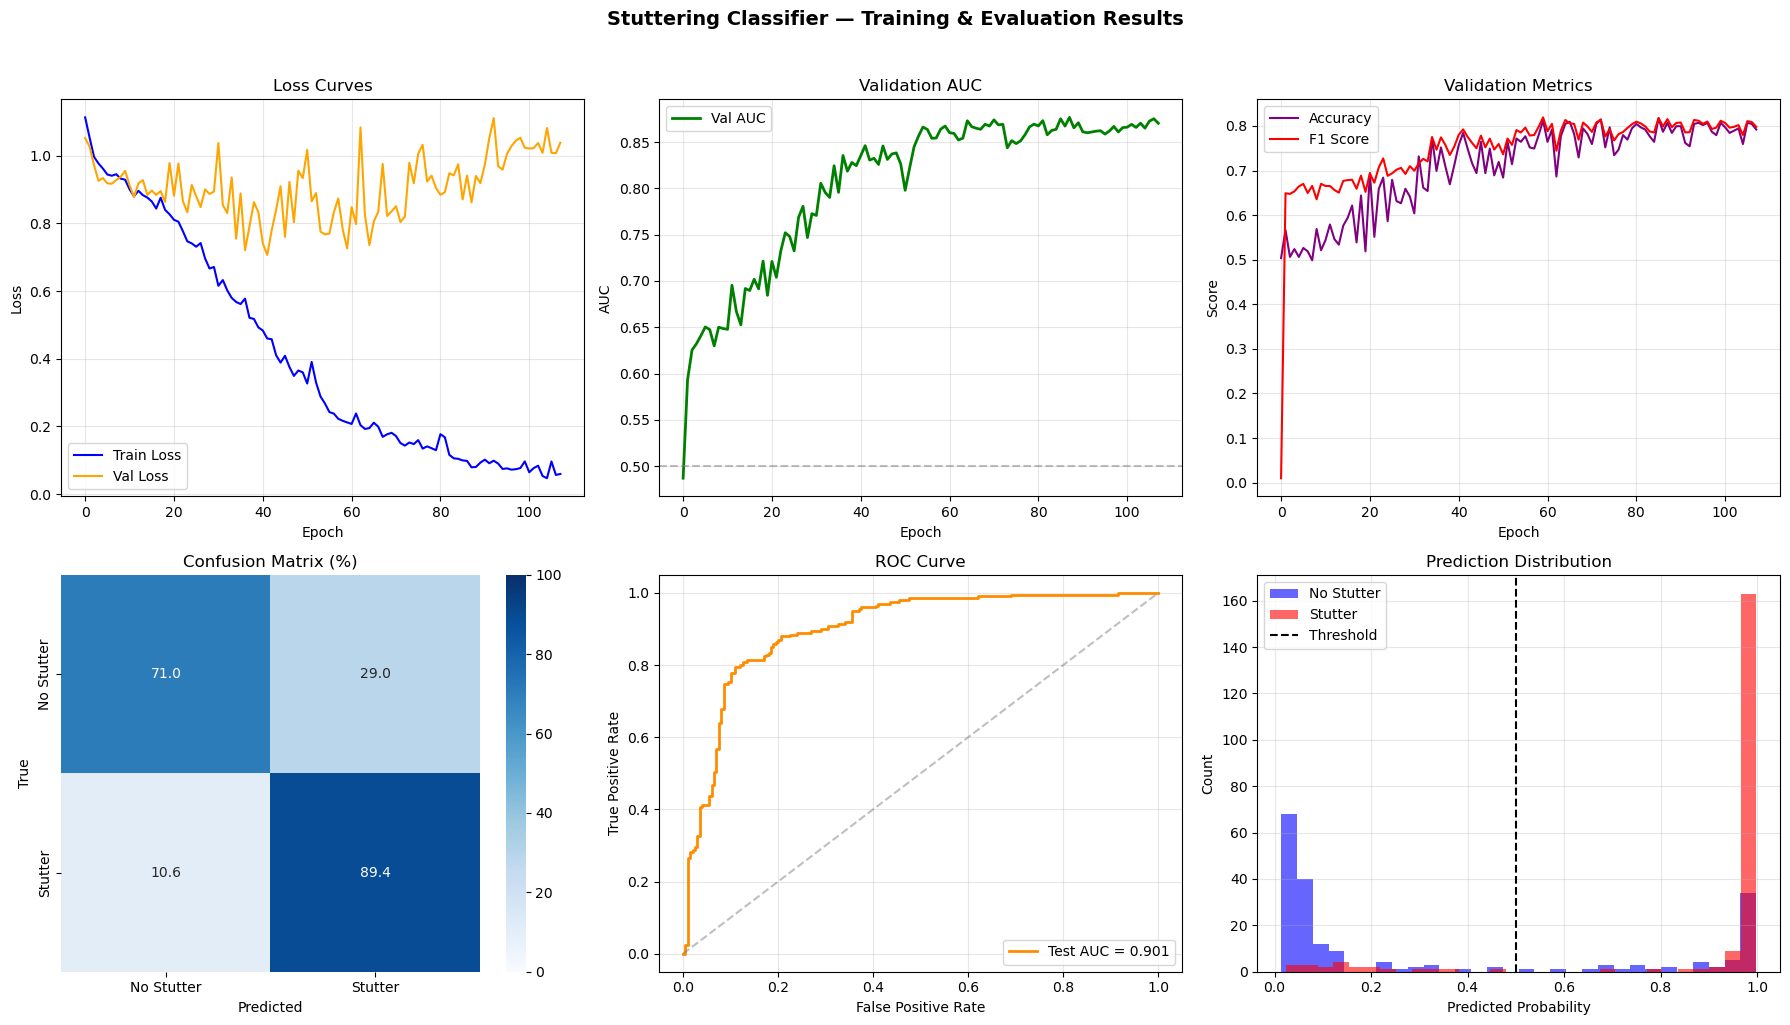


Plot saved: training_results.png

SAVED TO: output/working/models
  best_model.pt                     1.52 MB
  stutter_classifier_full.pt        1.53 MB
  stutter_classifier_weights.pt     1.52 MB
  history.json                      0.01 MB
  model_summary.json                0.00 MB
  training_results.png              0.30 MB

✅ Training complete. Best Val AUC: 0.8768 | Test AUC: 0.9009


In [10]:
# %% [code]
# ═══════════════════════════════════════════════════════════════════════════
# ⑦ PLOTS
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training curves
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='blue')
ax.plot(history['val_loss'], label='Val Loss', color='orange')
ax.set_title('Loss Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC curve
ax = axes[0, 1]
ax.plot(history['val_auc'], label='Val AUC', color='green', lw=2)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Validation AUC')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Accuracy & F1
ax = axes[0, 2]
ax.plot(history['val_acc'], label='Accuracy', color='purple')
ax.plot(history['val_f1'], label='F1 Score', color='red')
ax.set_title('Validation Metrics')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(test_labels, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalize

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            xticklabels=['No Stutter', 'Stutter'],
            yticklabels=['No Stutter', 'Stutter'],
            vmin=0, vmax=100)
ax.set_title('Confusion Matrix (%)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# 5. ROC Curve
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(test_labels, test_preds)
ax.plot(fpr, tpr, label=f'Test AUC = {test_metrics["auc"]:.3f}', lw=2, color='darkorange')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 6. Prediction distribution
ax = axes[1, 2]
ax.hist(test_preds[test_labels==0], bins=30, alpha=0.6, label='No Stutter', color='blue')
ax.hist(test_preds[test_labels==1], bins=30, alpha=0.6, label='Stutter', color='red')
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
ax.set_title('Prediction Distribution')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Stuttering Classifier — Training & Evaluation Results', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved: training_results.png")

# %% [code]
# ═══════════════════════════════════════════════════════════════════════════
# ⑧ SAVE MODEL & SUMMARY
# ═══════════════════════════════════════════════════════════════════════════

# Save full model (architecture + weights)
torch.save(model, os.path.join(OUT_DIR, 'stutter_classifier_full.pt'))

# Save just weights
torch.save(model.state_dict(), os.path.join(OUT_DIR, 'stutter_classifier_weights.pt'))

# Save training history
with open(os.path.join(OUT_DIR, 'history.json'), 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)

# Save model summary
model_summary = {
    "architecture": "Dual-Branch CNN-LSTM + MLP Ensemble",
    "input_shapes": {
        "X_frame": list(X_frame.shape),
        "X_clip": list(X_clip.shape),
    },
    "branches": {
        "temporal": {
            "input": f"(batch, {N_TIME_FRAMES}, {N_FRAME_FEAT})",
            "layers": ["Conv1D(45->64->128->128)", "BiLSTM(128, 2-layers)", "MultiheadAttention", "FC(256->128)"],
            "output_dim": 128,
        },
        "prosody": {
            "input": f"(batch, {N_CLIP_FEAT})",
            "layers": ["FC(32->64->32->16)"],
            "output_dim": 16,
        },
        "fusion": {
            "input": "Concatenate [128; 16] = 144",
            "layers": ["FC(144->64->1)"],
            "output": "logits (apply sigmoid for probability)",
        },
    },
    "training": {
        "epochs_trained": len(history['train_loss']),
        "best_val_auc": float(best_auc),
        "test_auc": float(test_metrics['auc']),
        "test_f1": float(test_metrics['f1']),
        "test_accuracy": float(test_metrics['accuracy']),
    },
    "parameters": total_params,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WD,
        "pos_weight": float(pos_weight.item()),
    },
}

with open(os.path.join(OUT_DIR, 'model_summary.json'), 'w') as f:
    json.dump(model_summary, f, indent=2)

print(f"\n{'='*60}")
print(f"SAVED TO: {OUT_DIR}")
print(f"{'='*60}")
for fn in ['best_model.pt', 'stutter_classifier_full.pt', 
           'stutter_classifier_weights.pt', 'history.json', 
           'model_summary.json', 'training_results.png']:
    fp = os.path.join(OUT_DIR, fn)
    if os.path.exists(fp):
        size_mb = os.path.getsize(fp) / 1e6
        print(f"  {fn:30s}  {size_mb:6.2f} MB")

print(f"\n✅ Training complete. Best Val AUC: {best_auc:.4f} | Test AUC: {test_metrics['auc']:.4f}")

In [11]:
import torch, os, datetime

checkpoint = {
    'model_state_dict': model.state_dict(),
    'timestamp': datetime.datetime.now().isoformat(),
}

# Uncomment the next two lines if you have `optimizer` and `epoch` variables:
# checkpoint['optimizer_state_dict'] = optimizer.state_dict()
# checkpoint['epoch'] = epoch

save_path = os.path.join(OUT_DIR, f"stutter_model_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pth")
torch.save(checkpoint, save_path)
print(f"Saved: {save_path} ({os.path.getsize(save_path)/1e6:.2f} MB)")

Saved: output/working/models/stutter_model_20260423_111502.pth (1.52 MB)
